# Chương 4. HỌC MÁY

### Thuật toán Hierarchical

Thuật toán phân cụm phân cấp (hierarchical clustering), được xây dựng dựa trên sơ đồ cây phân nhánh. Cây phân nhánh đóng vai trò như một thước đo thể hiện mức độ tương đồng giữa các điểm dữ liệu, giúp quan sát cấu trúc phân cấp của các cụm. Trong hierarchical clustering, mức độ tương đồng này được xác định dựa trên khoảng cách giữa các điểm dữ liệu hoặc giữa các cụm, tương tự như nguyên tắc trong nhiều thuật toán phân cụm khác:  

- Agglomerative (từ cụm nhỏ đến cụm lớn) với mỗi điểm dữ liệu ban đầu là một cụm riêng biệt và các cụm được hợp nhất cho đến khi toàn bộ dữ liệu thuộc về một cụm duy nhất.
- Divisive (từ cụm lớn đến cụm nhỏm) được bắt đầu bằng một cụm lớn rồi chia nhỏ dần thành các cụm nhỏ hơn.

Xây dựng thuật toán
Trong phần này chỉ trình bày phương pháp thông dụng nhất đi từ cụm nhỏ đến cụm lớn. Quá trình xây dựng thuật toán được mô tả chi tiết như sau:
- Bước 1: Mỗi điểm trong bộ dữ liệu đều được gán một phân cụm riêng biệt. 
- Bước 2: Xác định và sử dụng phương pháp liên kết (linkage) để tính khoảng cách giữa hai cụm:
  - Khoảng cách nhỏ nhất (single-linkage).
  - Khoảng cách dài nhất (complete-linkage).
  - Khoảng cách trung bình (average-linkage).

- Bước 3: Hợp nhất các phân cụm gần nhau.
- Bước 4: Cập nhật ma trận khoảng cách.
- Bước 5: Lặp lại quy trình cho đến khi chỉ còn một phân cụm duy nhất.
- Bước 6: Dựng đồ thị cây phân nhánh và xác định phân cụm phù hợp.


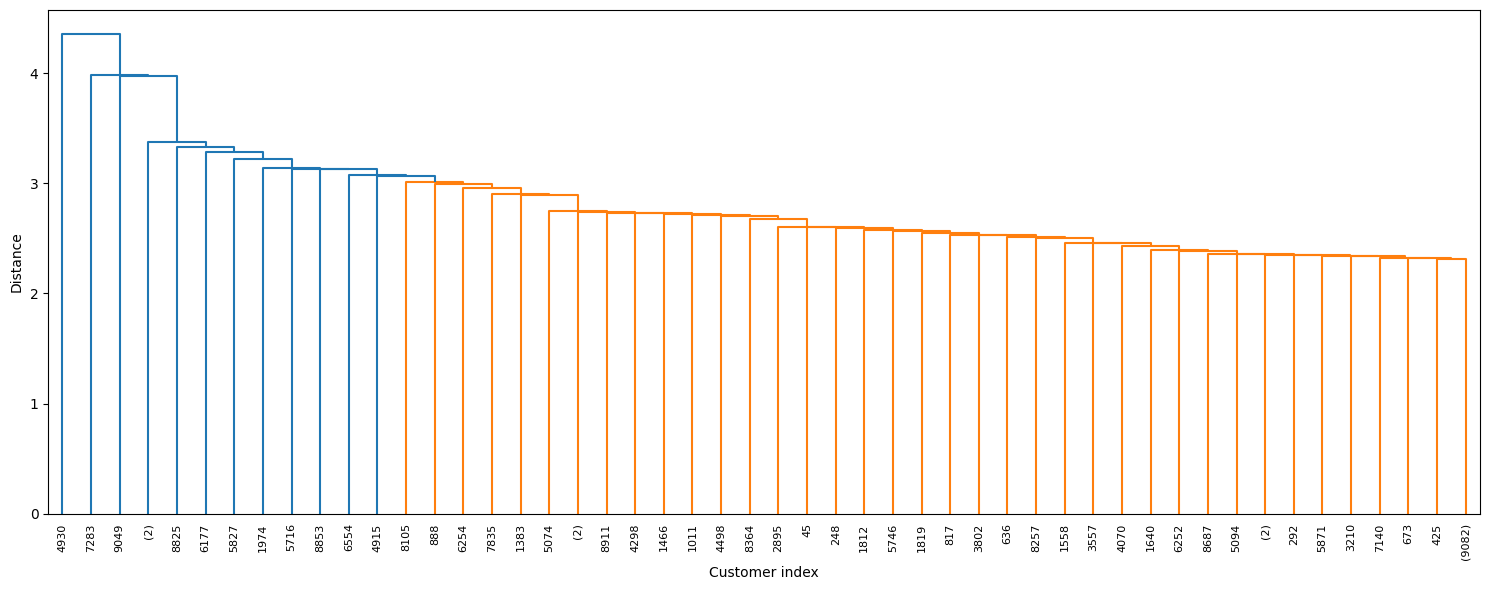

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import scipy.cluster.hierarchy as sch   
from scipy.cluster.hierarchy import fcluster

# Nhập dữ liệu
cus = pd.read_csv('../data/customer.csv')
cus_numeric = cus.select_dtypes(include=['int', 'float'])
cus_clean = cus_numeric.dropna(axis=1)

# Chuẩn hoá dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cus_clean)

# Giảm chiều bằng PCA
X_pca = PCA(n_components=5).fit_transform(X_scaled)

# Phân cụm bằng hierarchical clustering (single linkage)
Z = sch.linkage(X_scaled, method='single', metric='euclidean')

# Vẽ dendrogram
plt.figure(figsize=(15, 6))
sch.dendrogram(Z, truncate_mode='lastp', p=50, show_leaf_counts=True)
plt.xlabel("Customer index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

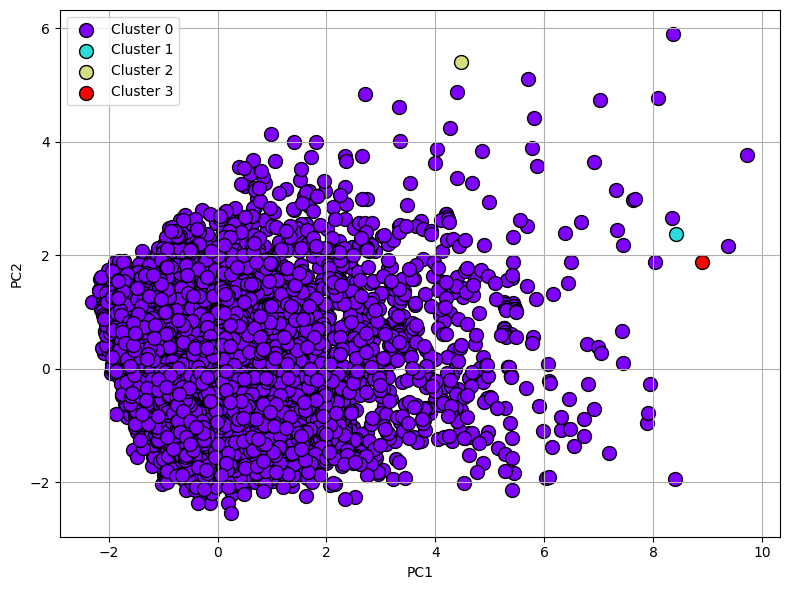

In [11]:
# Lấy nhãn cụm từ cây phân cấp
k = 4
labels = fcluster(Z, t=k, criterion='maxclust')  # 1..k

# Chuyển nhãn về 0..k-1 (ổn định theo thứ tự cụm)
old_to_new = {old: i for i, old in enumerate(sorted(np.unique(labels)))}
labels0 = np.vectorize(old_to_new.get)(labels)   # 0..k-1

# Trực quan
plt.figure(figsize=(8, 6))
unique_labels = np.unique(labels0)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    plt.scatter(
        X_pca[labels0 == label, 0],    # PC1
        X_pca[labels0 == label, 1],    # PC2
        edgecolors='black',
        linewidths=1.0,
        c=[color],
        label=f'Cluster {label}',
        s=100
    )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()